After my [prior blog post about SIGReg](/posts/sigreg-sketched-isotropic-gaussian-regularization/), I figured I'd train a small JEPA model to demonstate it.

The paper "LeWorldModel: Stable End-to-End Joint-Embedding Predictive Architecture from Pixels" [@maes2026] suggested significantly reducing the complexity of JEPA models by removing stop-gradients, and the exponential-moving-average encoder. This was in the context of world models and planning.

In this case, I'm applying JEPA to the task of creating word embeddings. Prior methodologies include Word2vec [@mikolov2013] which uses a log-linear model and negative sampling, MLP next-word prediction [@bengio2000], applying CCA to small context windows [@dhillon2011], and training an autoencoder on small context windows [@shao2025].

We'll be training a linear JEPA model with SIGReg on a small shakespeare dataset to show that it learns some informative embeddings. In other words, we'll train an encoder that turns two words into word embeddings, and train a linear predictor that predicts the second word embedding from the first. It would be easy to extend this methodology to non-linear encoders and use larger contexts than single words.

First lets start with the imports.

In [1]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import numpy as np
import requests
import re

# Preparing The Data

The Shakespeare Dataset is a text file containing Shakespeare's plays. 

In [2]:
txt_url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = requests.get(txt_url)
txt = response.text
txt[:100]

'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou'

To turn this into our dataset, we'll convert everything to lower-case, split out punctuation, and then split on spaces to get our tokens. We'll treat everything with frequency below 5 as an unknown token. The dataset consists of a single context word and the target word is simply the next word.

In [ ]:
# Lowercase then put spaces around punctuation and \n and then split on spaces
tokens = re.findall(r"\w+|[^\w\s]", txt.lower(), re.UNICODE)
print(tokens[:10])  # tokens[:10]

min_freq = 5
vocab_freq = pd.Series(tokens).value_counts()
vocab = vocab_freq[vocab_freq >= min_freq].index.tolist()
print("Vocab size: ", len(vocab))
print("First 10 vocab tokens: ", vocab[:10])

# add <unk> token for out-of-vocab words
vocab.append("<unk>")
token_to_id = {token: idx for idx, token in enumerate(vocab)}
id_to_token = {idx: token for idx, token in enumerate(vocab)}
def encode(tokens):
    return [token_to_id.get(token, token_to_id["<unk>"]) for token in tokens]

def decode(token_ids):
    return [id_to_token.get(token_id, "<unk>") for token_id in token_ids]  

encoded = encode(tokens)
print(encoded[:10])  # encoded[:10]

x0 = encoded[:-1]
x1 = encoded[1:]
print("Dataset size: ", len(x0))
pd.DataFrame({"x0": x0, "x1": x1}).head()


['first', 'citizen', ':', 'before', 'we', 'proceed', 'any', 'further', ',', 'hear']
Vocab size:  3234
First 10 vocab tokens:  [',', ':', '.', 'the', "'", 'and', 'i', 'to', 'of', ';']
[100, 283, 1, 152, 40, 985, 158, 678, 0, 137]
Dataset size:  262926


,x0,x1
0,100,283
1,283,1
2,1,152
3,152,40
4,40,985


# SIGReg
We use the same SIGReg code as in my [prior blog post](/posts/sigreg-sketched-isotropic-gaussian-regularization/). This is what makes the embedding space a bit Gaussian, avoiding dimensional collapse, as you'll see later in @fig-embspace which plots the first two embedding dimensions against each other.

In [4]:
def SIGReg(x, num_slices=256, k=17):
    # x: (N, D) samples
    N, D = x.shape
    device = x.device

    # --- Projection directions ---
    A = torch.randn(D, num_slices, device=device)
    A /= A.norm(dim=0)  # normalize columns → unit directions

    # Project to 1D: shape → (N, num_slices)
    X_proj = x @ A

    # --- Integration points ---
    t = torch.linspace(-5, 5, k, device=device)  # (k,)
    phi_normal = torch.exp(-0.5 * t**2)          # (k,)
    weight = phi_normal                          # Gaussian window

    # Broadcast shapes: (N, M, 1) ⋅ (1, 1, k)
    X_t = X_proj.unsqueeze(-1) * t

    # Empirical characteristic function across samples
    ecf = torch.exp(-1j * X_t).mean(dim=0)  # (M, k)

    # Squared difference
    diff_sq = (ecf - phi_normal).abs()**2  # (M, k)

    # Weighted integration for all projections → shape (M,)
    per_direction_T = torch.trapz(diff_sq * weight, t, dim=1) * N

    # GLOBAL aggregation — MEAN instead of MAX
    T_global = per_direction_T.mean()

    return T_global

# Making and Training The Embedding Model

Now we're ready to train a model. The encoder in this case is just an Embedding module and the predictor is just a Linear module. We use MSE loss comparing the predicted next word embedding versus the actual next word embedding as the objective function.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device: ", device)

x0 = torch.tensor(x0, dtype=torch.long).to(device)
x1 = torch.tensor(x1, dtype=torch.long).to(device)

embedding_dim = 10
hidden_dim = 64
encoder = torch.nn.Embedding(len(vocab), embedding_dim).to(device)
next_encoding_predictor = torch.nn.Linear(embedding_dim, embedding_dim).to(device)
sigreg_reg_lambda = 0.01

n_epochs = 10
batch_size = 512
optimizer = torch.optim.Adam(list(encoder.parameters()) + list(next_encoding_predictor.parameters()), lr=0.01)
loss_fn = torch.nn.MSELoss()
for epoch in range(n_epochs):
    total_loss = 0
    for i in range(0, len(x0), batch_size):
        x0_batch = x0[i:i+batch_size]
        x1_batch = x1[i:i+batch_size]
        
        x0_embedded = encoder(x0_batch)
        x1_embedded = encoder(x1_batch)
        
        x1_predicted = next_encoding_predictor(x0_embedded)
        
        loss = loss_fn(x1_predicted, x1_embedded)
        sigreg_loss = SIGReg(x0_embedded)
        loss += sigreg_reg_lambda*sigreg_loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    if (epoch+1) % (n_epochs // 10) == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {total_loss/len(x0)}")


Using device:  cuda
Epoch 1/10, Loss: 0.001497643509146753
Epoch 2/10, Loss: 0.0013701475152272003
Epoch 3/10, Loss: 0.001300397162714445
Epoch 4/10, Loss: 0.0012644762265178317
Epoch 5/10, Loss: 0.0012466884210328192
Epoch 6/10, Loss: 0.0012368921435588504
Epoch 7/10, Loss: 0.0012292570233309666
Epoch 8/10, Loss: 0.0012229596484082204
Epoch 9/10, Loss: 0.0012185444856821132
Epoch 10/10, Loss: 0.0012142995094667748


# Visualize

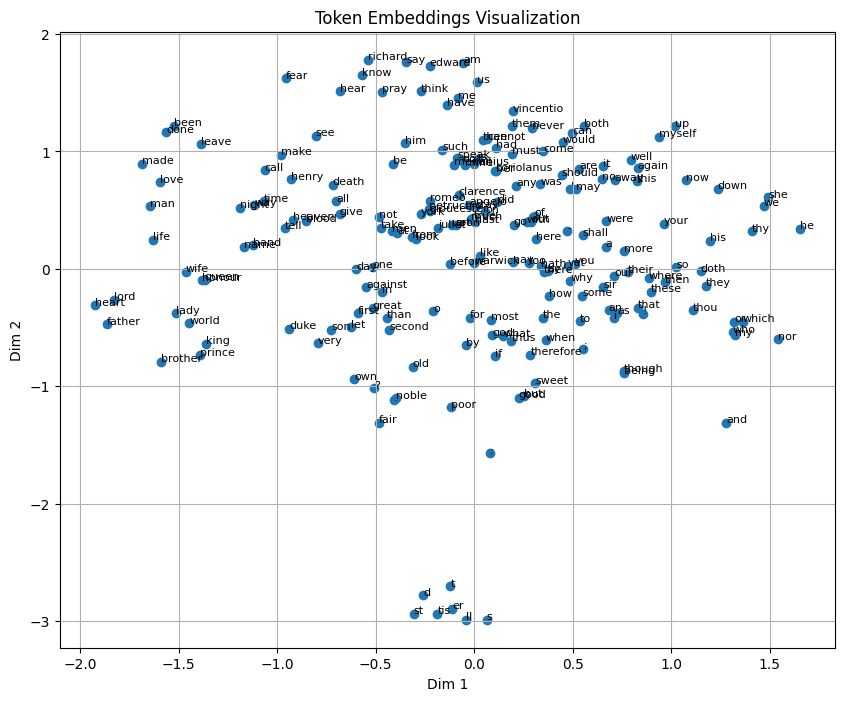

In [ ]:
#| label: fig-embspace

def visualize_embeddings(encoder, vocab, token_to_id, max_tokens=200):
    """
    Visualize token embeddings.
    
    If embedding_dim == 2 → plot directly.
    If embedding_dim > 2 → plot first 2 dimensions
    
    max_tokens limits how many tokens to plot for readability.
    """

    # optionally limit tokens for clarity
    tokens = vocab[:max_tokens]
    indices = [token_to_id[t] for t in tokens]
    emb_subset = encoder(torch.tensor(indices).to(next(encoder.parameters()).device)).detach().cpu().numpy()
    

    # plot
    plt.figure(figsize=(10, 8))
    plt.scatter(emb_subset[:, 0], emb_subset[:, 1])
    
    # annotate tokens
    for i, token in enumerate(tokens):
        plt.annotate(token, (emb_subset[i, 0], emb_subset[i, 1]), fontsize=8)
    
    plt.title("Token Embeddings Visualization")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.grid()
    plt.show()

visualize_embeddings(encoder, vocab, token_to_id)


In the visualization above we can see several clusters including character names, royal titles, and tokens that follow apostrophes in words like ne'er, 'tis and o'er. This shows that the JEPA model is learning informative embeddings.

# Further Embedding Investigation

We can also observe what words are closest in embedding space. For example, it's encouraging that "prince" is near the word "king", "juliet" is near the word "romeo" and "wolves" is near the word "dogs".

In [19]:
def neighbour_table_l2(words, n=5):
    device = next(encoder.parameters()).device
    encoder.eval()

    vocab_ids = torch.arange(len(vocab)).to(device)

    with torch.no_grad():
        vocab_emb = encoder(vocab_ids)

    rows = []

    word_order = {w: i for i, w in enumerate(words)}

    for word in words:
        if word not in token_to_id:
            continue

        word_id = token_to_id[word]

        with torch.no_grad():
            query_emb = encoder(torch.tensor([word_id]).to(device))

            x_sq = (query_emb ** 2).sum(dim=1, keepdim=True)
            v_sq = (vocab_emb ** 2).sum(dim=1).unsqueeze(0)
            cross = torch.matmul(query_emb, vocab_emb.T)

            distances = (x_sq + v_sq - 2 * cross).squeeze(0)

            distances[word_id] = float("inf")

            top_ids = torch.topk(-distances, n).indices.tolist()

        for rank, i in enumerate(top_ids, 1):
            rows.append({
                "query": word,
                "query_order": word_order[word],
                "rank": rank,
                "token": id_to_token[i],
                "l2_distance": distances[i].item()
            })

    df = pd.DataFrame(rows)

    # enforce deterministic ordering for display
    df = df.sort_values(["query_order", "rank"])

    pivot_tokens = (
        df.pivot(index="query", columns="rank", values="token")
        .reindex(words)
    ).T

    display(pivot_tokens)

    return df


# ---- run ----
words = ["the", "old", "king", "romeo", "fears", "dogs"]
df = neighbour_table_l2(words, n=5)

query,the,old,king,romeo,fears,dogs
rank,,,,,,
1,their,mighty,prince,juliet,guest,mine
2,meaner,trusty,maiden,benvolio,scorns,wolves
3,your,airy,fourth,biondello,affections,pain
4,our,honest,tyranny,paulina,hour,england
5,yon,youthful,custom,norfolk,serpent,cover


# Future Directions

As I mentioned earlier, it would be easy to extend this methodology to non-linear (e.g. MLP, CNN, RNN, Transformer) models and use larger contexts and targets than single words. It's also possible to play around with other hyperparameters like SIGReg regularizer coefficient, embedding dimension, and hidden dimension and try larger datasets.

Compared to many prior methods for getting word embeddings, this does appear to be less complicated than things like negative sampling (e.g. word2vec). 

There's also recent work on approximations to SIGReg that are likely more computationally efficient with very little downside [@akbar2026].

